In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input



In [ ]:
MODEL_PATH = "Modelos/best_dog_emotion_model_final_2.keras"  # Cambia esto por tu archivo real

model = tf.keras.models.load_model(MODEL_PATH)

print("Modelo cargado correctamente")
model.summary()

In [24]:

class_names = ["angry", "happy", "relaxed", "sad"]

def convertir_a_jpg_si_es_necesario(ruta_imagen):
    extension = os.path.splitext(ruta_imagen)[1].lower()

    if extension in [".jpg", ".jpeg"]:
        return ruta_imagen

    nueva_ruta = os.path.splitext(ruta_imagen)[0] + ".jpg"

    img = Image.open(ruta_imagen)

    img = img.convert("RGB")

    img.save(nueva_ruta, "JPEG", quality=95)

    print(f"Imagen convertida a JPG: {nueva_ruta}")

    return nueva_ruta

In [29]:
def predecir_imagen(ruta_imagen):
    img_size = (224, 224)

    ruta_imagen = convertir_a_jpg_si_es_necesario(ruta_imagen)

    img = image.load_img(ruta_imagen, target_size=img_size)

    img_array = image.img_to_array(img)

    img_array_batch = np.expand_dims(img_array, axis=0)

    img_preprocesada = preprocess_input(img_array_batch)

    prediccion = model.predict(img_preprocesada)

    indice_predicho = np.argmax(prediccion[0])
    clase_predicha = class_names[indice_predicho]
    confianza = prediccion[0][indice_predicho]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicción: {clase_predicha} | Confianza: {confianza*100:.2f}%")
    plt.show()

    print("Clase predicha:", clase_predicha)
    print(f"Confianza: {confianza*100:.2f}%")

    print("\nArray de probabilidades:")
    print(prediccion[0])

    print("\nProbabilidades por clase:")
    for clase, prob in zip(class_names, prediccion[0]):
        print(f"{clase}: {prob*100:.2f}%")

    return clase_predicha, confianza, prediccion[0]

Imagen convertida a JPG: Test_data/perro_7.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


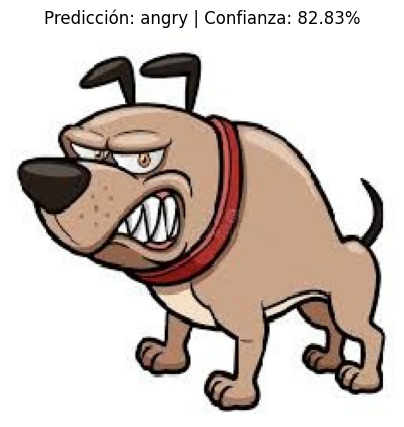

Clase predicha: angry
Confianza: 82.83%

Array de probabilidades:
[0.8283185  0.14384381 0.01971146 0.00812626]

Probabilidades por clase:
angry: 82.83%
happy: 14.38%
relaxed: 1.97%
sad: 0.81%


In [33]:
ruta = "Test_data/perro_7.jfif" 

clase, confianza, probabilidades = predecir_imagen(ruta)